# 05 - Candidatos diferenciales y resumen del proyecto

Selección de un conjunto pequeño de variantes candidatas aplicando criterios explícitos, y
construcción de las figuras y tablas finales que resumen el proyecto completo.

**Pregunta que responde este notebook:** de todo lo observado en las tres capas, ¿qué 2–5
patrones merecen destacarse como candidatos diferenciales, y con qué evidencia se justifican?

**Entradas** (las generan los notebooks 01, 02 y 03)
- `results/tables/frecuencias_variantes.csv` — frecuencia de cada variante de DNA por grupo
- `results/tables/dna_a_proteina.csv` — efecto proteico de cada variante
- `results/tables/paciente_x_variante.csv` — quién porta qué
- `results/tables/clinica_para_integracion.csv` — capa clínica por paciente
- `results/tables/frecuencias_cambios_proteicos.csv` — cambios aminoacídicos por grupo

**Salidas principales**
- `results/tables/evaluacion_criterios.csv` — cada variante frente a los 5 criterios
- `results/tables/perfil_clinico_portadores.csv` — comparación portadores vs. no portadores
- `results/tables/candidatos_diferenciales.csv` — tabla final de candidatos
- `results/figures/candidatos/` — figuras de cierre

> Datos **sintéticos** de uso docente. Todo lo observado es asociación descriptiva.


**Uso de IA:** se usó apoyo de IA (Claude) para corregir la ruta de acceso a los datos y verificar que el notebook ejecute de punta a punta sin errores. La sección de conclusiones (9) quedó como plantilla a propósito, pendiente de que el equipo la complete con los valores reales de la ejecución.

## 0. Configuración

Los criterios de selección son decisiones del grupo y se declaran arriba, en constantes, para
que se puedan defender y modificar sin buscarlas en medio del código.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"Sano": "#4C72B0", "Alzheimer": "#DD8452"}
PALETA_PORTADOR = {"No portador": "#8C8C8C", "Portador": "#C44E52"}

GENES = ["APP", "PSEN1", "PSEN2", "APOE", "TREM2"]

# ---- Umbrales de los criterios (decisiones del grupo) ----
MIN_PORTADORES     = 10    # criterio 1: recurrencia
MIN_DIF_PUNTOS     = 10.0  # criterio 2: diferencia de frecuencia entre grupos
MIN_EFECTO_CLINICO = 0.20  # criterio 4: |d| o diferencia de prevalencia relevante
N_CANDIDATOS_FINAL = 5     # cuántos candidatos se llevan a la presentación

### Ruta del proyecto

**Esta misma línea debe estar en los cinco notebooks.** Es la única forma de garantizar que todos
lean y escriban en la misma carpeta `results/`.

La celda verifica antes de crear nada: si la ruta está mal, avisa y **no deja carpetas vacías
sueltas**, que es lo que causa confusión cuando hay más de una copia del proyecto descargada.

In [2]:
# notebooks/ -> raiz del proyecto
DIR_PROYECTO = Path.cwd().parent

DIR_RESULTADOS = DIR_PROYECTO / "results"
DIR_TABLAS     = DIR_RESULTADOS / "tables"
DIR_FIGURAS    = DIR_RESULTADOS / "figures"

# --- Verificar ANTES de crear nada ---
if not DIR_PROYECTO.exists():
    raise FileNotFoundError(f"No existe la carpeta del proyecto:\n  {DIR_PROYECTO}")
if not DIR_TABLAS.exists():
    raise FileNotFoundError(
        f"No existe {DIR_TABLAS}.\nEjecuta antes los notebooks 01 a 04 apuntando a esta"
        f" misma DIR_PROYECTO.")

ARCHIVOS = {
    "frecuencias_dna":      DIR_TABLAS / "frecuencias_variantes.csv",
    "dna_a_proteina":       DIR_TABLAS / "dna_a_proteina.csv",
    "paciente_x_variante":  DIR_TABLAS / "paciente_x_variante.csv",
    "clinica":              DIR_TABLAS / "clinica_para_integracion.csv",
    "frecuencias_proteina": DIR_TABLAS / "frecuencias_cambios_proteicos.csv",
}

# Opcionales: si falta el dataset integrado del notebook 04, se reconstruye aqui
OPCIONALES = {
    "integrado":    DIR_TABLAS / "dataset_integrado.csv",
    "dna_capa":     DIR_TABLAS / "dna_para_integracion.csv",
    "proteina_capa": DIR_TABLAS / "proteina_para_integracion.csv",
}

print("Proyecto:", DIR_PROYECTO.name)
print("Tablas en:", DIR_TABLAS, "\n")

faltan = []
for etiqueta, ruta in ARCHIVOS.items():
    existe = ruta.exists()
    print(f"   {etiqueta:<22} {'OK   ' if existe else 'FALTA'} {ruta.name}")
    if not existe:
        faltan.append(ruta.name)

for etiqueta, ruta in OPCIONALES.items():
    print(f"   {etiqueta:<22} {'OK   ' if ruta.exists() else '-    '} {ruta.name}")

if faltan:
    print("\nCSV disponibles en esa carpeta:")
    for p in sorted(DIR_TABLAS.glob("*.csv")):
        print("   ", p.name)
    raise FileNotFoundError("Faltan: " + ", ".join(faltan)
                            + "\nRevisa que los notebooks 01 a 04 usen la misma DIR_PROYECTO.")

# Recien ahora, con todo verificado, se crea la carpeta de figuras
(DIR_FIGURAS / "candidatos").mkdir(parents=True, exist_ok=True)


def guardar_figura(nombre, subcarpeta="candidatos"):
    ruta = DIR_FIGURAS / subcarpeta / f"{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    return ruta


def guardar_tabla(df, nombre, index=False):
    ruta = DIR_TABLAS / f"{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


print("\nTodo listo. Resultados en:", DIR_RESULTADOS)

Proyecto: intr_2026_trabajo_final
Tablas en: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results/tables 

   frecuencias_dna        OK    frecuencias_variantes.csv
   dna_a_proteina         OK    dna_a_proteina.csv
   paciente_x_variante    OK    paciente_x_variante.csv
   clinica                OK    clinica_para_integracion.csv
   frecuencias_proteina   OK    frecuencias_cambios_proteicos.csv
   integrado              OK    dataset_integrado.csv
   dna_capa               OK    dna_para_integracion.csv
   proteina_capa          OK    proteina_para_integracion.csv

Todo listo. Resultados en: /home/hisoka/Escritorio/trabajointro/intr_2026_trabajo_final/results


---
## 1. Lectura de los insumos

Cada notebook anterior dejó su parte del trabajo ya resumida. Aquí no se recalcula nada: este
notebook solo **combina y prioriza** lo que ya existe.

In [3]:
frecuencias_dna      = pd.read_csv(ARCHIVOS["frecuencias_dna"])
dna_a_proteina       = pd.read_csv(ARCHIVOS["dna_a_proteina"])
portadores           = pd.read_csv(ARCHIVOS["paciente_x_variante"], index_col=0)
clinica              = pd.read_csv(ARCHIVOS["clinica"])
frecuencias_proteina = pd.read_csv(ARCHIVOS["frecuencias_proteina"])
if OPCIONALES["integrado"].exists():
    integrado = pd.read_csv(OPCIONALES["integrado"])
    print("Dataset integrado leido del notebook 04.")
elif OPCIONALES["dna_capa"].exists() and OPCIONALES["proteina_capa"].exists():
    # Reconstruccion: mismo merge que hace el notebook 04
    _dna  = pd.read_csv(OPCIONALES["dna_capa"]).drop(columns=["alzheimer"], errors="ignore")
    _prot = pd.read_csv(OPCIONALES["proteina_capa"]).drop(columns=["alzheimer"], errors="ignore")
    integrado = (clinica.drop(columns=["diagnostico"], errors="ignore")
                 .merge(_dna, on="patient_id", how="inner")
                 .merge(_prot, on="patient_id", how="inner"))
    print("Dataset integrado reconstruido desde las tres capas (el 04 no lo habia generado).")
else:
    raise FileNotFoundError(
        "No encuentro dataset_integrado.csv ni las capas para reconstruirlo. "
        "Ejecuta el notebook 04, o al menos 01, 02 y 03.")

if "diagnostico" not in integrado.columns:
    integrado["diagnostico"] = integrado["alzheimer"].map({0: "Sano", 1: "Alzheimer"})
enf = integrado[integrado["alzheimer"] == 1]
san = integrado[integrado["alzheimer"] == 0]

clinica["diagnostico"] = clinica["alzheimer"].map({0: "Sano", 1: "Alzheimer"})

print("Variantes de DNA recurrentes :", len(frecuencias_dna))
print("Variantes con efecto proteico:", len(dna_a_proteina))
print("Matriz paciente x variante   :", portadores.shape)
print("Pacientes en la capa clinica :", len(clinica))
print("Cambios proteicos recurrentes:", len(frecuencias_proteina))
print("Dataset integrado            :", integrado.shape)

frecuencias_dna.head()

Dataset integrado leido del notebook 04.
Variantes de DNA recurrentes : 14
Variantes con efecto proteico: 14
Matriz paciente x variante   : (1000, 14)
Pacientes en la capa clinica : 1000
Cambios proteicos recurrentes: 496
Dataset integrado            : (1000, 545)


,variante_id,gene,tipo,posicion,n_total,n_alzheimer,n_sano,pct_sano,pct_alzheimer,diferencia_puntos,razon
0,APOE:205:T>G,APOE,SNP,205,333,206,127,19.33,60.06,40.73,3.11
1,APOE:311:C>T,APOE,SNP,311,333,206,127,19.33,60.06,40.73,3.11
2,PSEN1:133:C>A,PSEN1,SNP,133,109,90,19,2.89,26.24,23.35,9.07
3,TREM2:251:C>A,TREM2,SNP,251,85,66,19,2.89,19.24,16.35,6.65
4,APP:217:G>C,APP,SNP,217,92,67,25,3.81,19.53,15.73,5.13


---
## 2. Los cinco criterios de selección

La guía (sección 4.5) propone cinco criterios. La idea de este notebook es **implementarlos uno
por uno** en vez de elegir candidatos a ojo, de modo que la tabla final sea reproducible y cada
fila se pueda justificar.

| Criterio | Pregunta práctica | Cómo se evalúa aquí |
|---|---|---|
| Recurrencia | ¿Aparece en varios pacientes? | `n_total >= MIN_PORTADORES` |
| Diferencia entre grupos | ¿La frecuencia difiere entre sanos y casos? | `diferencia_puntos >= MIN_DIF_PUNTOS` |
| Efecto proteico | ¿Altera la proteína? | missense, frameshift o indel in-frame (no sinónima) |
| Relación clínica | ¿Los portadores difieren clínicamente? | comparación portadores vs. no portadores |
| Interpretabilidad | ¿Se explica con una figura sencilla? | se cumple si los 4 anteriores son claros |

Los umbrales son decisiones del grupo, no criterios estándar. Están declarados en la sección 0 y
hay que poder defenderlos: bajarlos aumenta el número de candidatos y también el ruido.

### Criterios 1 y 2 — recurrencia y diferencia entre grupos

In [4]:
criterios = frecuencias_dna[["variante_id", "gene", "tipo", "posicion",
                             "n_total", "pct_sano", "pct_alzheimer",
                             "diferencia_puntos", "razon"]].copy()

criterios["c1_recurrencia"] = criterios["n_total"] >= MIN_PORTADORES
criterios["c2_diferencia"]  = criterios["diferencia_puntos"].abs() >= MIN_DIF_PUNTOS

print(f"Cumplen recurrencia (>= {MIN_PORTADORES} portadores): "
      f"{criterios['c1_recurrencia'].sum()} de {len(criterios)}")
print(f"Cumplen diferencia (>= {MIN_DIF_PUNTOS} puntos):      "
      f"{criterios['c2_diferencia'].sum()} de {len(criterios)}")

criterios[["variante_id", "n_total", "pct_sano", "pct_alzheimer",
           "diferencia_puntos", "razon", "c1_recurrencia", "c2_diferencia"]]

Cumplen recurrencia (>= 10 portadores): 14 de 14
Cumplen diferencia (>= 10.0 puntos):      9 de 14


,variante_id,n_total,pct_sano,pct_alzheimer,diferencia_puntos,razon,c1_recurrencia,c2_diferencia
0,APOE:205:T>G,333,19.33,60.06,40.73,3.11,True,True
1,APOE:311:C>T,333,19.33,60.06,40.73,3.11,True,True
2,PSEN1:133:C>A,109,2.89,26.24,23.35,9.07,True,True
3,TREM2:251:C>A,85,2.89,19.24,16.35,6.65,True,True
4,APP:217:G>C,92,3.81,19.53,15.73,5.13,True,True
5,TREM2:529:C>A,66,1.98,15.45,13.47,7.81,True,True
6,PSEN1:374:C>G,72,2.74,15.74,13.00,5.75,True,True
7,PSEN2:615:T>G,58,2.13,12.83,10.70,6.02,True,True
8,APP:452:C>G,69,3.35,13.70,10.35,4.09,True,True
9,PSEN2:166:T>C,56,2.44,11.66,9.23,4.79,True,False


### Criterio 3 — efecto proteico

Una variante que no altera la proteína es menos interesante como candidata, porque difícilmente
explique una diferencia funcional. El notebook 03 ya clasificó cada variante recurrente.

In [5]:
criterios = criterios.merge(
    dna_a_proteina[["variante_dna", "pos_aa", "aa_referencia", "aa_portadores",
                    "efecto_proteico", "pct_portadores_cambio_extenso"]],
    left_on="variante_id", right_on="variante_dna", how="left").drop(columns="variante_dna")

criterios["c3_efecto_proteico"] = criterios["efecto_proteico"].isin(
    ["missense", "frameshift", "indel in-frame"])

print("Reparto de efectos proteicos:")
display(criterios["efecto_proteico"].value_counts().rename("n"))

criterios[["variante_id", "pos_aa", "aa_referencia", "aa_portadores",
           "efecto_proteico", "c3_efecto_proteico"]]

Reparto de efectos proteicos:


efecto_proteico
missense          10
indel in-frame     2
frameshift         2
Name: n, dtype: int64

,variante_id,pos_aa,aa_referencia,aa_portadores,efecto_proteico,c3_efecto_proteico
0,APOE:205:T>G,69,C,G,missense,True
1,APOE:311:C>T,104,T,I,missense,True
2,PSEN1:133:C>A,45,H,N,missense,True
3,TREM2:251:C>A,84,T,K,missense,True
4,APP:217:G>C,73,A,P,missense,True
5,TREM2:529:C>A,177,Q,K,missense,True
6,PSEN1:374:C>G,125,T,R,missense,True
7,PSEN2:615:T>G,205,N,K,missense,True
8,APP:452:C>G,151,A,G,missense,True
9,PSEN2:166:T>C,56,S,P,missense,True


### Criterio 4 — relación clínica, controlando por diagnóstico

El más exigente de los cinco, y el que hace real la integración. La pregunta es si **los
portadores se ven clínicamente distintos de los no portadores**.

Hay una trampa que hay que sortear. Todas estas variantes están enriquecidas en casos, y los casos
son en promedio 9 años mayores y tienen más antecedente familiar. Entonces, si uno compara
portadores contra no portadores sin más, **cualquier variante va a parecer asociada a mayor edad**,
simplemente porque sus portadores son mayoritariamente casos. La señal sería un reflejo del
diagnóstico, no un efecto de la variante.

La solución es la misma que en el notebook 01 con la edad: **comparar dentro de cada grupo
diagnóstico**. Si la diferencia persiste entre los controles portadores y los controles no
portadores, y también entre los casos, entonces no se explica solo por el diagnóstico.

Se calculan ambas versiones para poder mostrar el contraste.

In [6]:
def d_de_cohen(x, y):
    """Diferencia de medias en unidades de desviacion estandar combinada."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return 0.0
    s = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return float((x.mean() - y.mean()) / s) if s > 0 else 0.0


VARS_CLINICAS = [c for c in clinica.columns
                 if c not in ("patient_id", "alzheimer", "diagnostico")]
VARS_BINARIAS = [c for c in VARS_CLINICAS
                 if set(clinica[c].dropna().unique()) <= {0, 1}]
VARS_NUMERICAS = [c for c in VARS_CLINICAS if c not in VARS_BINARIAS]

print("Variables clinicas numericas:", VARS_NUMERICAS)
print("Variables clinicas binarias :", VARS_BINARIAS)

base = clinica.merge(portadores.reset_index(names="patient_id"),
                     on="patient_id", how="left")
base[portadores.columns] = base[portadores.columns].fillna(0).astype(int)

def comparar(con, sin, var, binaria):
    """Devuelve (valor_no_portador, valor_portador, magnitud)."""
    if binaria:
        p_sin, p_con = sin[var].mean() * 100, con[var].mean() * 100
        return p_sin, p_con, p_con - p_sin
    return sin[var].mean(), con[var].mean(), d_de_cohen(con[var], sin[var])


def normalizar(magnitud, binaria):
    """Lleva binarias y numericas a una escala aproximadamente comparable."""
    return abs(magnitud) / 50 if binaria else abs(magnitud)


filas = []
for variante in criterios["variante_id"]:
    if variante not in base.columns:
        continue

    con_all = base[base[variante] == 1]
    sin_all = base[base[variante] == 0]
    if len(con_all) < 2 or len(sin_all) < 2:
        continue

    for var in VARS_NUMERICAS + VARS_BINARIAS:
        binaria = var in VARS_BINARIAS

        # --- version cruda: portadores vs no portadores, toda la cohorte ---
        v_sin, v_con, magnitud = comparar(con_all, sin_all, var, binaria)

        # --- version ajustada: dentro de cada grupo diagnostico ---
        magnitudes, signos = [], []
        for etiqueta in (0, 1):
            estrato = base[base["alzheimer"] == etiqueta]
            con = estrato[estrato[variante] == 1]
            sin = estrato[estrato[variante] == 0]
            if len(con) < 5 or len(sin) < 5:
                continue
            _, _, m = comparar(con, sin, var, binaria)
            magnitudes.append(m)
            signos.append(np.sign(m))

        if magnitudes:
            magnitud_ajustada = float(np.mean(magnitudes))
            consistente = len(set(signos)) == 1 and len(magnitudes) == 2
        else:
            magnitud_ajustada, consistente = np.nan, False

        filas.append({
            "variante_id": variante,
            "variable": var,
            "tipo_variable": "binaria" if binaria else "numerica",
            "valor_no_portador": v_sin,
            "valor_portador": v_con,
            "magnitud_cruda": magnitud,
            "magnitud_ajustada": magnitud_ajustada,
            "mismo_signo_en_ambos_grupos": consistente,
            "unidad": "puntos porcentuales" if binaria else "d de Cohen",
            "norm_cruda": normalizar(magnitud, binaria),
            "norm_ajustada": normalizar(magnitud_ajustada, binaria) if magnitudes else np.nan,
        })

perfil_clinico = pd.DataFrame(filas).round(4)
guardar_tabla(perfil_clinico, "perfil_clinico_portadores")

print(f"\nComparaciones calculadas: {len(perfil_clinico)}")
perfil_clinico.head(12)

Variables clinicas numericas: ['age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg']
Variables clinicas binarias : ['hypertension', 'family_history_alzheimer', 'sex_female']



Comparaciones calculadas: 84


,variante_id,variable,tipo_variable,valor_no_portador,valor_portador,magnitud_cruda,magnitud_ajustada,mismo_signo_en_ambos_grupos,unidad,norm_cruda,norm_ajustada
0,APOE:205:T>G,age,numerica,67.7091,70.9520,0.2990,-0.0598,True,d de Cohen,0.2990,0.0598
1,APOE:205:T>G,systolic_bp_mmHg,numerica,130.2489,131.9339,0.1206,-0.1074,True,d de Cohen,0.1206,0.1074
2,APOE:205:T>G,diastolic_bp_mmHg,numerica,79.9400,78.5766,-0.1611,-0.2818,True,d de Cohen,0.1611,0.2818
3,APOE:205:T>G,hypertension,binaria,32.9835,37.5375,4.5540,-6.1822,True,puntos porcentuales,0.0911,0.1236
4,APOE:205:T>G,family_history_alzheimer,binaria,19.1904,31.8318,12.6414,5.1295,True,puntos porcentuales,0.2528,0.1026
5,APOE:205:T>G,sex_female,binaria,53.0735,58.2583,5.1848,6.1025,True,puntos porcentuales,0.1037,0.1220
6,APOE:311:C>T,age,numerica,67.7091,70.9520,0.2990,-0.0598,True,d de Cohen,0.2990,0.0598
7,APOE:311:C>T,systolic_bp_mmHg,numerica,130.2489,131.9339,0.1206,-0.1074,True,d de Cohen,0.1206,0.1074
8,APOE:311:C>T,diastolic_bp_mmHg,numerica,79.9400,78.5766,-0.1611,-0.2818,True,d de Cohen,0.1611,0.2818
9,APOE:311:C>T,hypertension,binaria,32.9835,37.5375,4.5540,-6.1822,True,puntos porcentuales,0.0911,0.1236


In [7]:
# Para cada variante se conserva la senal clinica ajustada mas fuerte,
# exigiendo que apunte en la misma direccion en controles y en casos.
validas = perfil_clinico[perfil_clinico["mismo_signo_en_ambos_grupos"]].copy()

mejor_senal = (validas
               .sort_values("norm_ajustada", ascending=False)
               .groupby("variante_id", as_index=False)
               .first()[["variante_id", "variable", "tipo_variable",
                         "valor_no_portador", "valor_portador",
                         "magnitud_cruda", "magnitud_ajustada", "unidad",
                         "norm_ajustada"]]
               .rename(columns={"variable": "variable_clinica"}))

criterios = criterios.merge(mejor_senal, on="variante_id", how="left")
criterios["c4_relacion_clinica"] = (criterios["norm_ajustada"]
                                    >= MIN_EFECTO_CLINICO).fillna(False)

print(f"Cumplen relacion clinica ajustada (>= {MIN_EFECTO_CLINICO}): "
      f"{criterios['c4_relacion_clinica'].sum()} de {len(criterios)}")

criterios[["variante_id", "variable_clinica", "valor_no_portador", "valor_portador",
           "magnitud_cruda", "magnitud_ajustada", "unidad",
           "c4_relacion_clinica"]].sort_values("variante_id")

Cumplen relacion clinica ajustada (>= 0.2): 10 de 14


,variante_id,variable_clinica,valor_no_portador,valor_portador,magnitud_cruda,magnitud_ajustada,unidad,c4_relacion_clinica
0,APOE:205:T>G,diastolic_bp_mmHg,79.9400,78.5766,-0.1611,-0.2818,d de Cohen,True
1,APOE:311:C>T,diastolic_bp_mmHg,79.9400,78.5766,-0.1611,-0.2818,d de Cohen,True
4,APP:217:G>C,hypertension,32.3789,55.4348,23.0559,10.7186,puntos porcentuales,True
8,APP:452:C>G,systolic_bp_mmHg,130.5188,134.7391,0.3025,0.1791,d de Cohen,False
12,APP:688:TCC>-,hypertension,34.4041,37.1429,2.7387,-9.9330,puntos porcentuales,False
2,PSEN1:133:C>A,systolic_bp_mmHg,130.5903,132.6055,0.1442,-0.3028,d de Cohen,True
6,PSEN1:374:C>G,systolic_bp_mmHg,130.4537,135.4028,0.3552,0.1733,d de Cohen,False
10,PSEN1:612:->GCT,diastolic_bp_mmHg,79.5010,79.1591,-0.0403,-0.2381,d de Cohen,True
9,PSEN2:166:T>C,sex_female,54.0254,67.8571,13.8317,14.3343,puntos porcentuales,True
11,PSEN2:407:GC>-,family_history_alzheimer,22.2453,52.6316,30.3863,30.5831,puntos porcentuales,True


**El contraste entre las dos columnas es el resultado interesante.** `magnitud_cruda` es lo
que se ve al comparar portadores contra no portadores sin más; `magnitud_ajustada` es el promedio
de esa misma comparación hecha dentro de controles y dentro de casos por separado.

Cuando la ajustada cae cerca de cero, la diferencia cruda era un reflejo del diagnóstico: los
portadores parecían distintos solo porque la mayoría eran casos. Poder mostrar esa distinción es
justo lo que la pauta evalúa en la dimensión de rigor.

### Criterio 5 — interpretabilidad y puntaje final

El quinto criterio de la guía es cualitativo: que el patrón se pueda explicar con una tabla o una
figura sencilla. Aquí se aproxima de forma transparente: una variante es interpretable si cumple
al menos tres de los cuatro criterios anteriores, porque ahí existe una historia completa que
contar (frecuencia, efecto molecular y correlato clínico).

In [8]:
COLS_CRITERIOS = ["c1_recurrencia", "c2_diferencia",
                  "c3_efecto_proteico", "c4_relacion_clinica"]

criterios["n_criterios"] = criterios[COLS_CRITERIOS].sum(axis=1)
criterios["c5_interpretable"] = criterios["n_criterios"] >= 3
criterios["puntaje"] = criterios["n_criterios"] + criterios["c5_interpretable"].astype(int)

criterios = criterios.sort_values(
    ["puntaje", "diferencia_puntos"], ascending=[False, False]).reset_index(drop=True)

guardar_tabla(criterios, "evaluacion_criterios")

print("Distribucion de puntajes (maximo 5):")
display(criterios["puntaje"].value_counts().sort_index(ascending=False).rename("n_variantes"))

criterios[["variante_id", "efecto_proteico", "diferencia_puntos",
           "variable_clinica", "magnitud_ajustada"] + COLS_CRITERIOS +
          ["c5_interpretable", "puntaje"]]

Distribucion de puntajes (maximo 5):


puntaje
5    6
4    7
2    1
Name: n_variantes, dtype: int64

,variante_id,efecto_proteico,diferencia_puntos,variable_clinica,magnitud_ajustada,c1_recurrencia,c2_diferencia,c3_efecto_proteico,c4_relacion_clinica,c5_interpretable,puntaje
0,APOE:205:T>G,missense,40.73,diastolic_bp_mmHg,-0.2818,True,True,True,True,True,5
1,APOE:311:C>T,missense,40.73,diastolic_bp_mmHg,-0.2818,True,True,True,True,True,5
2,PSEN1:133:C>A,missense,23.35,systolic_bp_mmHg,-0.3028,True,True,True,True,True,5
3,APP:217:G>C,missense,15.73,hypertension,10.7186,True,True,True,True,True,5
4,TREM2:529:C>A,missense,13.47,family_history_alzheimer,22.4446,True,True,True,True,True,5
5,PSEN2:615:T>G,missense,10.70,family_history_alzheimer,29.7077,True,True,True,True,True,5
6,TREM2:251:C>A,missense,16.35,systolic_bp_mmHg,0.1956,True,True,True,False,True,4
7,PSEN1:374:C>G,missense,13.00,systolic_bp_mmHg,0.1733,True,True,True,False,True,4
8,APP:452:C>G,missense,10.35,systolic_bp_mmHg,0.1791,True,True,True,False,True,4
9,PSEN2:166:T>C,missense,9.23,sex_female,14.3343,True,False,True,True,True,4


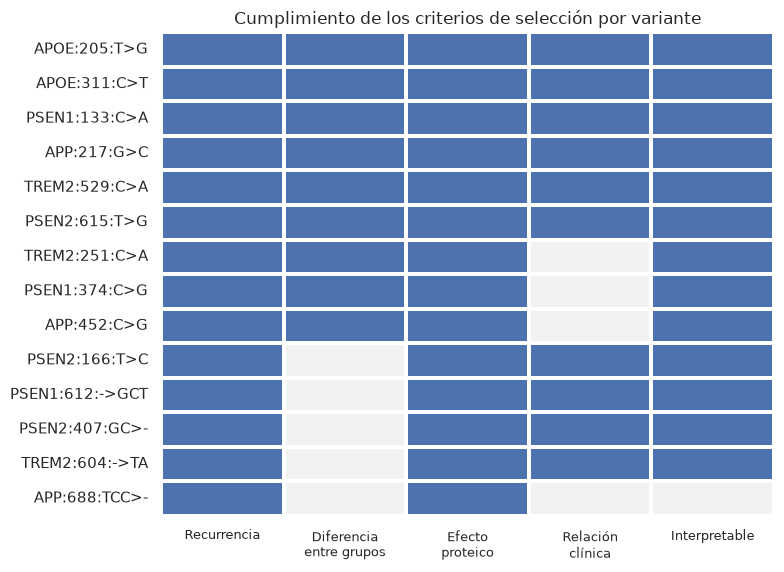

In [9]:
# Mapa de calor: cada variante frente a cada criterio
mapa = criterios.set_index("variante_id")[COLS_CRITERIOS + ["c5_interpretable"]].astype(int)
mapa.columns = ["Recurrencia", "Diferencia\nentre grupos", "Efecto\nproteico",
                "Relación\nclínica", "Interpretable"]

fig, ax = plt.subplots(figsize=(8, max(4, 0.42 * len(mapa))))
sns.heatmap(mapa, cmap=["#F2F2F2", "#4C72B0"], cbar=False, linewidths=1.5,
            linecolor="white", ax=ax)
ax.set(title="Cumplimiento de los criterios de selección por variante", xlabel="", ylabel="")
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
guardar_figura("matriz_criterios")
plt.show()

### Variantes equivalentes: un haplotipo no son dos candidatos

El notebook 02 mostró que `APOE:205:T>G` y `APOE:311:C>T` aparecen exactamente en los mismos
pacientes: son dos SNPs ligados, un solo haplotipo. Si se cuentan como dos candidatos ocupan dos
lugares de la lista final sin aportar evidencia independiente.

Aquí se detectan automáticamente las variantes con conjuntos de portadores idénticos y se agrupan,
conservando una como representante y dejando registro de la otra.

In [10]:
# Dos variantes son equivalentes si su columna de portadores es identica
firmas = {}
for variante in criterios["variante_id"]:
    if variante not in portadores.columns:
        continue
    firma = tuple(portadores[variante].values)
    firmas.setdefault(firma, []).append(variante)

grupos = {}
equivalentes = {}
for i, (firma, miembros) in enumerate(firmas.items(), start=1):
    etiqueta = f"H{i:02d}"
    for v in miembros:
        grupos[v] = etiqueta
        equivalentes[v] = ", ".join(m for m in miembros if m != v) or "-"

criterios["grupo_haplotipo"] = criterios["variante_id"].map(grupos)
criterios["variantes_equivalentes"] = criterios["variante_id"].map(equivalentes)

ligadas = {k: v for k, v in firmas.items() if len(v) > 1}
print(f"Grupos de variantes con portadores identicos: {len(ligadas)}")
for miembros in ligadas.values():
    print("   ligadas:", " + ".join(miembros))

# Un representante por grupo, el de mayor puntaje
representantes = (criterios.sort_values(["puntaje", "diferencia_puntos"],
                                        ascending=[False, False])
                  .groupby("grupo_haplotipo", as_index=False).first())
representantes = representantes.sort_values(["puntaje", "diferencia_puntos"],
                                            ascending=[False, False]).reset_index(drop=True)

print(f"\nVariantes recurrentes: {len(criterios)} -> grupos independientes: "
      f"{len(representantes)}")
representantes[["variante_id", "variantes_equivalentes", "puntaje", "diferencia_puntos"]]

Grupos de variantes con portadores identicos: 1
   ligadas: APOE:205:T>G + APOE:311:C>T

Variantes recurrentes: 14 -> grupos independientes: 13


,variante_id,variantes_equivalentes,puntaje,diferencia_puntos
0,APOE:205:T>G,APOE:311:C>T,5,40.73
1,PSEN1:133:C>A,-,5,23.35
2,APP:217:G>C,-,5,15.73
3,TREM2:529:C>A,-,5,13.47
4,PSEN2:615:T>G,-,5,10.70
5,TREM2:251:C>A,-,4,16.35
6,PSEN1:374:C>G,-,4,13.00
7,APP:452:C>G,-,4,10.35
8,PSEN2:166:T>C,-,4,9.23
9,PSEN1:612:->GCT,-,4,8.39


---
## 3. Tabla de candidatos diferenciales

Los candidatos son las variantes con mayor puntaje. Cada fila lleva una justificación en una
línea, construida con sus propios números, para que la tabla se pueda leer sin volver al código.

In [11]:
def justificar(fila):
    partes = []
    partes.append(f"{fila['n_total']} portadores")
    partes.append(f"{fila['pct_alzheimer']:.1f}% en casos vs {fila['pct_sano']:.1f}% en controles")
    if pd.notna(fila["razon"]):
        partes.append(f"{fila['razon']:.1f}x")
    if pd.notna(fila["efecto_proteico"]):
        if fila["efecto_proteico"] == "missense":
            partes.append(f"missense {fila['aa_referencia']}{int(fila['pos_aa'])}"
                          f"{fila['aa_portadores']}")
        else:
            partes.append(str(fila["efecto_proteico"]))
    if pd.notna(fila.get("variable_clinica")):
        signo = "+" if fila["magnitud_ajustada"] > 0 else ""
        partes.append(f"{fila['variable_clinica']} {signo}{fila['magnitud_ajustada']:.2f} "
                      f"({fila['unidad']}, ajustado por diagnostico)")
    return "; ".join(partes)


candidatos = representantes.head(N_CANDIDATOS_FINAL).copy()
candidatos["justificacion"] = candidatos.apply(justificar, axis=1)

tabla_final = candidatos[["variante_id", "variantes_equivalentes",
                          "gene", "tipo", "posicion", "n_total",
                          "pct_sano", "pct_alzheimer", "diferencia_puntos", "razon",
                          "efecto_proteico", "variable_clinica", "magnitud_cruda",
                          "magnitud_ajustada", "puntaje", "justificacion"]].round(2)

guardar_tabla(tabla_final, "candidatos_diferenciales")
tabla_final

,variante_id,variantes_equivalentes,gene,tipo,posicion,n_total,pct_sano,pct_alzheimer,diferencia_puntos,razon,efecto_proteico,variable_clinica,magnitud_cruda,magnitud_ajustada,puntaje,justificacion
0,APOE:205:T>G,APOE:311:C>T,APOE,SNP,205,333,19.33,60.06,40.73,3.11,missense,diastolic_bp_mmHg,-0.16,-0.28,5,333 portadores; 60.1% en casos vs 19.3% en con...
1,PSEN1:133:C>A,-,PSEN1,SNP,133,109,2.89,26.24,23.35,9.07,missense,systolic_bp_mmHg,0.14,-0.30,5,109 portadores; 26.2% en casos vs 2.9% en cont...
2,APP:217:G>C,-,APP,SNP,217,92,3.81,19.53,15.73,5.13,missense,hypertension,23.06,10.72,5,92 portadores; 19.5% en casos vs 3.8% en contr...
3,TREM2:529:C>A,-,TREM2,SNP,529,66,1.98,15.45,13.47,7.81,missense,family_history_alzheimer,26.86,22.44,5,66 portadores; 15.4% en casos vs 2.0% en contr...
4,PSEN2:615:T>G,-,PSEN2,SNP,615,58,2.13,12.83,10.70,6.02,missense,family_history_alzheimer,31.90,29.71,5,58 portadores; 12.8% en casos vs 2.1% en contr...


---
## 4. Perfil clínico de los portadores

El criterio 4 se resume en un número, pero conviene mirarlo desplegado: para cada candidato, cómo
se ven los portadores frente a los no portadores en todas las variables clínicas.

Advertencia de interpretación: si una variante está enriquecida en casos y los casos son mayores,
los portadores van a parecer mayores **aunque la variante no tenga nada que ver con la edad**. La
señal clínica de un portador puede ser un reflejo del diagnóstico, no un efecto propio.

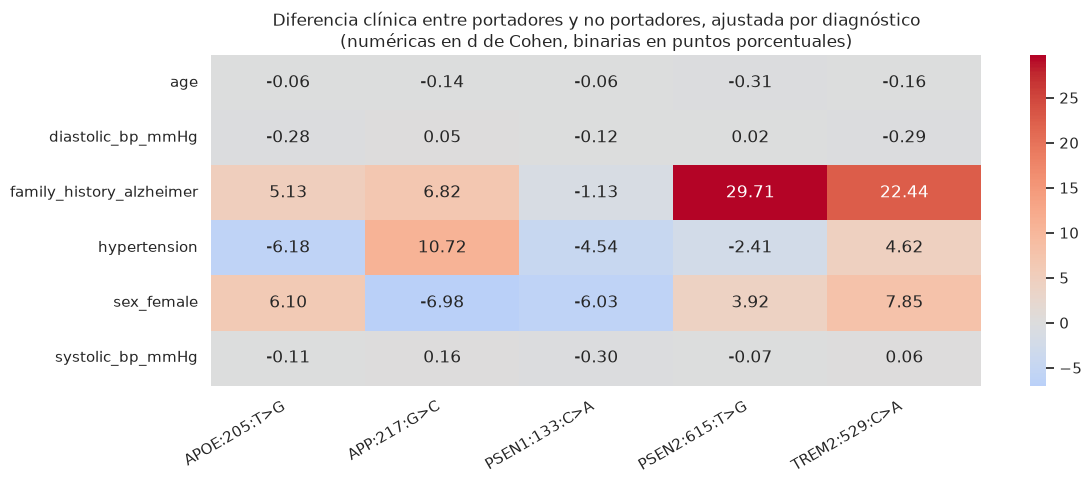

In [12]:
vars_candidatas = candidatos["variante_id"].tolist()
sub = perfil_clinico[perfil_clinico["variante_id"].isin(vars_candidatas)].copy()

pivote = sub.pivot(index="variable", columns="variante_id", values="magnitud_ajustada")

fig, ax = plt.subplots(figsize=(1.6 * len(vars_candidatas) + 4, 5))
sns.heatmap(pivote, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set(title="Diferencia clínica entre portadores y no portadores, ajustada por diagnóstico\n"
             "(numéricas en d de Cohen, binarias en puntos porcentuales)",
       xlabel="", ylabel="")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
guardar_figura("perfil_clinico_candidatos")
plt.show()

---
## 5. Grupos de interés

La guía propone construir grupos combinando evidencia de varias capas. El ejemplo que da es
"pacientes con una mutación recurrente + cambio aminoacídico asociado + mayor frecuencia de
hipertensión".

Aquí se arma ese grupo con el candidato principal y se compara contra el resto de la cohorte.

In [13]:
VARIANTE_FOCO = candidatos["variante_id"].iloc[0]
print("Candidato principal:", VARIANTE_FOCO)

base["grupo_interes"] = np.where(base[VARIANTE_FOCO] == 1, "Portador", "No portador")

resumen_grupo = (base.groupby("grupo_interes")
                 .agg(n_pacientes=("patient_id", "count"),
                      pct_alzheimer=("alzheimer", lambda s: s.mean() * 100),
                      **{v: (v, "mean") for v in VARS_NUMERICAS},
                      **{v: (v, lambda s: s.mean() * 100) for v in VARS_BINARIAS})
                 .round(2))

display(resumen_grupo.T)

# Riesgo relativo dentro de la cohorte (descriptivo, no causal)
p_port = base.loc[base[VARIANTE_FOCO] == 1, "alzheimer"].mean()
p_nopo = base.loc[base[VARIANTE_FOCO] == 0, "alzheimer"].mean()
print(f"\nProporcion de casos entre portadores    : {p_port * 100:.1f}%")
print(f"Proporcion de casos entre no portadores : {p_nopo * 100:.1f}%")
print(f"Razon: {p_port / p_nopo:.2f}x  (descriptivo dentro de esta cohorte sintetica)")

Candidato principal: APOE:205:T>G


grupo_interes,No portador,Portador
n_pacientes,667.00,333.00
pct_alzheimer,20.54,61.86
age,67.71,70.95
systolic_bp_mmHg,130.25,131.93
diastolic_bp_mmHg,79.94,78.58
hypertension,32.98,37.54
family_history_alzheimer,19.19,31.83
sex_female,53.07,58.26



Proporcion de casos entre portadores    : 61.9%
Proporcion de casos entre no portadores : 20.5%
Razon: 3.01x  (descriptivo dentro de esta cohorte sintetica)


---
## 6. Visualización integrada

La figura que pide la guía: una sola imagen que conecte un cambio genético, su efecto proteico y
una característica clínica, terminando en el diagnóstico. Es la candidata natural para la
diapositiva de integración.

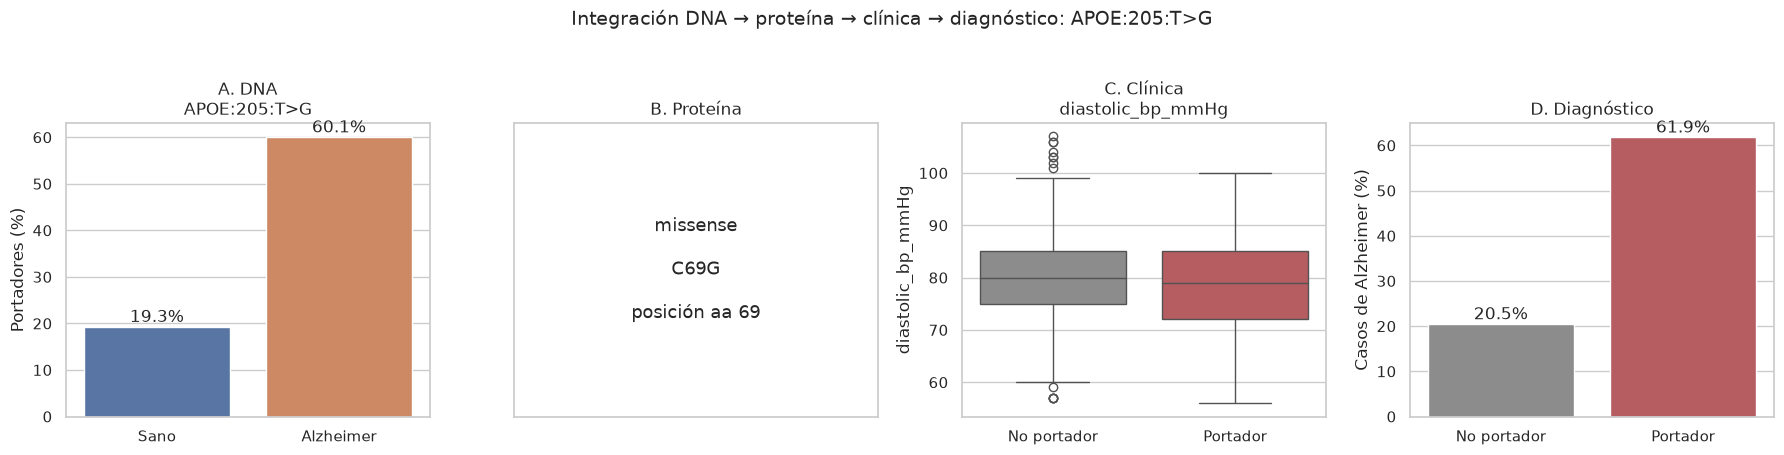

In [14]:
fila_foco = candidatos[candidatos["variante_id"] == VARIANTE_FOCO].iloc[0]

fig, ax = plt.subplots(1, 4, figsize=(18, 4.4))

# A. DNA: frecuencia de la variante por grupo
datos_a = pd.DataFrame({"grupo": ["Sano", "Alzheimer"],
                        "pct": [fila_foco["pct_sano"], fila_foco["pct_alzheimer"]]})
sns.barplot(data=datos_a, x="grupo", y="pct", hue="grupo", palette=PALETA,
            legend=False, ax=ax[0])
for i, v in enumerate(datos_a["pct"]):
    ax[0].text(i, v + 1, f"{v:.1f}%", ha="center")
ax[0].set(title=f"A. DNA\n{VARIANTE_FOCO}", xlabel="", ylabel="Portadores (%)")

# B. Proteina: efecto del cambio
if pd.notna(fila_foco["efecto_proteico"]):
    if fila_foco["efecto_proteico"] == "missense":
        texto = (f"{fila_foco['efecto_proteico']}\n\n"
                 f"{fila_foco['aa_referencia']}{int(fila_foco['pos_aa'])}"
                 f"{fila_foco['aa_portadores']}\n\n"
                 f"posición aa {int(fila_foco['pos_aa'])}")
    else:
        texto = (f"{fila_foco['efecto_proteico']}\n\n"
                 f"{fila_foco['pct_portadores_cambio_extenso']:.0f}% de portadores\n"
                 f"con cambio extenso")
else:
    texto = "sin efecto\nproteico registrado"
ax[1].text(0.5, 0.5, texto, ha="center", va="center", fontsize=13,
           transform=ax[1].transAxes)
ax[1].set(title="B. Proteína", xticks=[], yticks=[])
ax[1].grid(False)

# C. Clinica: variable con mayor senal entre portadores
var_cl = fila_foco["variable_clinica"]
if var_cl in VARS_BINARIAS:
    datos_c = (base.groupby("grupo_interes")[var_cl].mean() * 100).reset_index()
    sns.barplot(data=datos_c, x="grupo_interes", y=var_cl, hue="grupo_interes",
                palette=PALETA_PORTADOR, legend=False, ax=ax[2])
    ax[2].set(title=f"C. Clínica\n{var_cl}", xlabel="", ylabel="Prevalencia (%)")
else:
    sns.boxplot(data=base, x="grupo_interes", y=var_cl, hue="grupo_interes",
                palette=PALETA_PORTADOR, legend=False, ax=ax[2])
    ax[2].set(title=f"C. Clínica\n{var_cl}", xlabel="", ylabel=var_cl)

# D. Diagnostico
datos_d = (base.groupby("grupo_interes")["alzheimer"].mean() * 100).reset_index()
sns.barplot(data=datos_d, x="grupo_interes", y="alzheimer", hue="grupo_interes",
            palette=PALETA_PORTADOR, legend=False, ax=ax[3])
for i, v in enumerate(datos_d["alzheimer"]):
    ax[3].text(i, v + 1, f"{v:.1f}%", ha="center")
ax[3].set(title="D. Diagnóstico", xlabel="", ylabel="Casos de Alzheimer (%)")

fig.suptitle(f"Integración DNA → proteína → clínica → diagnóstico: {VARIANTE_FOCO}",
             fontsize=14, y=1.03)
plt.tight_layout()
guardar_figura("integracion_candidato_principal")
plt.show()

---
## 7. Figuras de resumen del proyecto

El punto 4.6 de la guía pide un conjunto de figuras que cuenten la historia completa: una por
capa, más una integrada. Se construyen desde `dataset_integrado.csv`, que ya tiene las tres capas
unidas por `patient_id`.

### 7.1 Resumen de la cohorte clínica

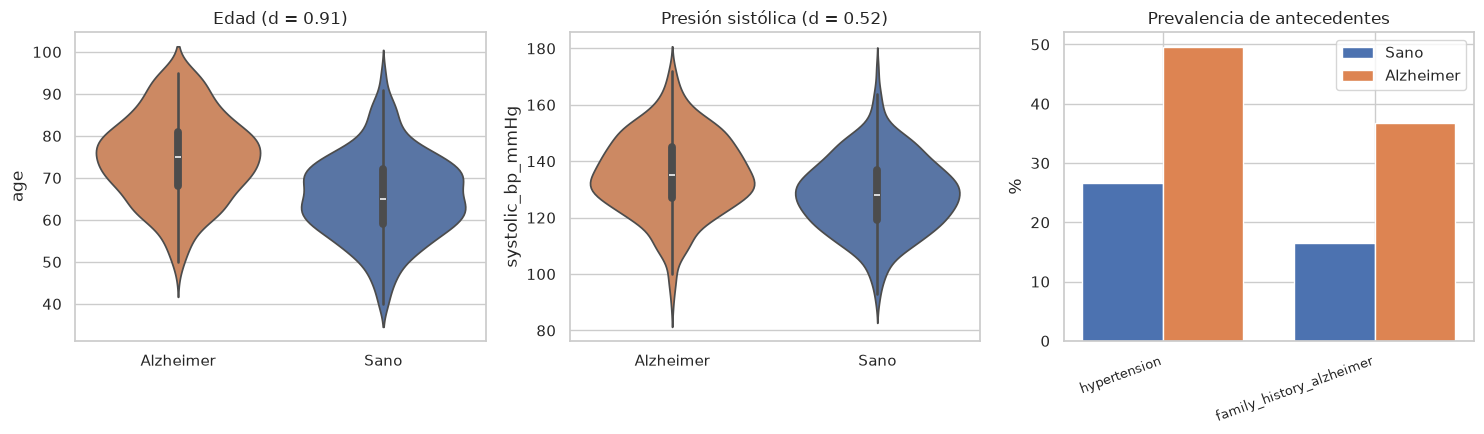

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.violinplot(data=integrado, x="diagnostico", y="age", hue="diagnostico",
               palette=PALETA, legend=False, ax=axes[0])
d_edad = d_de_cohen(enf["age"], san["age"])
axes[0].set(title=f"Edad (d = {d_edad:.2f})", xlabel="")

sns.violinplot(data=integrado, x="diagnostico", y="systolic_bp_mmHg", hue="diagnostico",
               palette=PALETA, legend=False, ax=axes[1])
d_sis = d_de_cohen(enf["systolic_bp_mmHg"], san["systolic_bp_mmHg"])
axes[1].set(title=f"Presión sistólica (d = {d_sis:.2f})", xlabel="")

bins = [b for b in ["hypertension", "family_history_alzheimer"] if b in integrado.columns]
prev = integrado.groupby("diagnostico")[bins].mean().reindex(["Sano", "Alzheimer"]) * 100
x, ancho = np.arange(len(bins)), 0.38
axes[2].bar(x - ancho / 2, prev.loc["Sano"], ancho, label="Sano", color=PALETA["Sano"])
axes[2].bar(x + ancho / 2, prev.loc["Alzheimer"], ancho, label="Alzheimer",
            color=PALETA["Alzheimer"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(bins, rotation=20, ha="right", fontsize=9)
axes[2].set(title="Prevalencia de antecedentes", ylabel="%")
axes[2].legend(title="")

plt.tight_layout()
guardar_figura("resumen_cohorte_clinica")
plt.show()

### 7.2 Mutaciones de DNA por gen

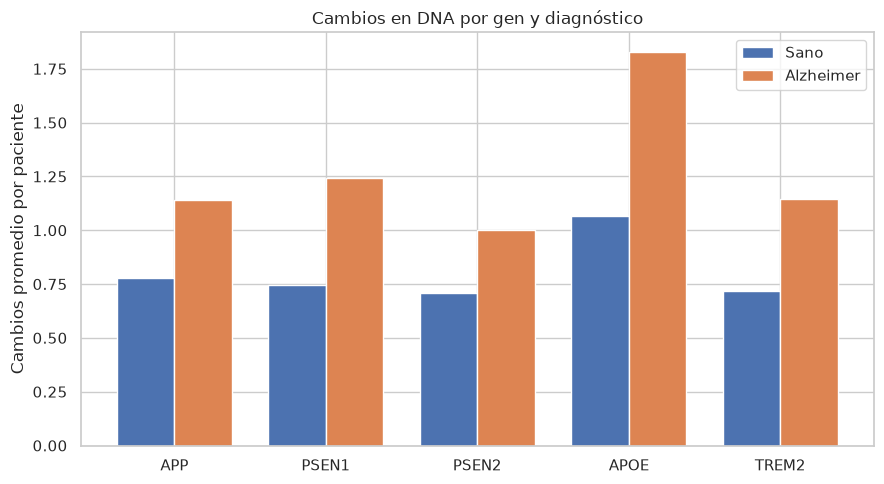

In [16]:
genes_presentes = [g for g in GENES if f"n_cambios_{g}" in integrado.columns]
cols_gen = [f"n_cambios_{g}" for g in genes_presentes]
medias_gen = integrado.groupby("diagnostico")[cols_gen].mean().reindex(["Sano", "Alzheimer"])

x, ancho = np.arange(len(genes_presentes)), 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho / 2, medias_gen.loc["Sano"], ancho, label="Sano", color=PALETA["Sano"])
ax.bar(x + ancho / 2, medias_gen.loc["Alzheimer"], ancho, label="Alzheimer",
       color=PALETA["Alzheimer"])
ax.set_xticks(x)
ax.set_xticklabels(genes_presentes)
ax.set(ylabel="Cambios promedio por paciente",
       title="Cambios en DNA por gen y diagnóstico")
ax.legend(title="")
plt.tight_layout()
guardar_figura("resumen_dna_por_gen")
plt.show()

El exceso de cambios en el grupo Alzheimer **no está repartido por igual entre los genes**: se
concentra en los que contienen las variantes enriquecidas. Eso refuerza la conclusión del
notebook 02: no hay un exceso general de mutaciones, hay variantes específicas.

### 7.3 Cambios proteicos por diagnóstico

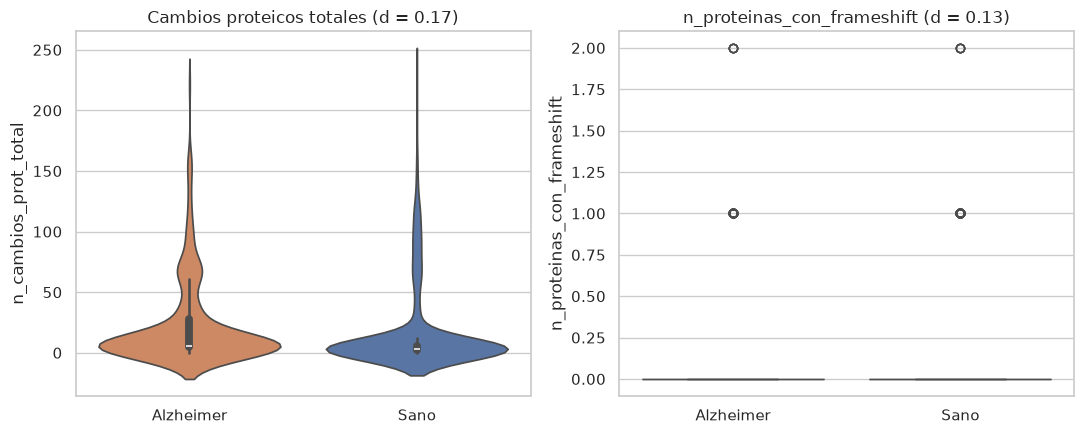

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

col_prot = next((c for c in ["n_cambios_prot_total", "carga_total_prot"]
                 if c in integrado.columns), None)
if col_prot:
    sns.violinplot(data=integrado, x="diagnostico", y=col_prot, hue="diagnostico",
                   palette=PALETA, legend=False, ax=axes[0])
    d_prot = d_de_cohen(enf[col_prot], san[col_prot])
    axes[0].set(title=f"Cambios proteicos totales (d = {d_prot:.2f})", xlabel="")
else:
    axes[0].axis("off")

prop = next((c for c in ["n_proteinas_con_frameshift", "carga_neta_APOE",
                         "frac_hidrofobica_APOE"] if c in integrado.columns), None)
if prop:
    sns.boxplot(data=integrado, x="diagnostico", y=prop, hue="diagnostico",
                palette=PALETA, legend=False, ax=axes[1])
    d_prop = d_de_cohen(enf[prop], san[prop])
    axes[1].set(title=f"{prop} (d = {d_prop:.2f})", xlabel="")
else:
    axes[1].axis("off")

plt.tight_layout()
guardar_figura("resumen_proteina")
plt.show()

---
## 8. Figura de cierre del proyecto

Un panel único con lo esencial de las tres capas, pensado como última diapositiva de respaldo.

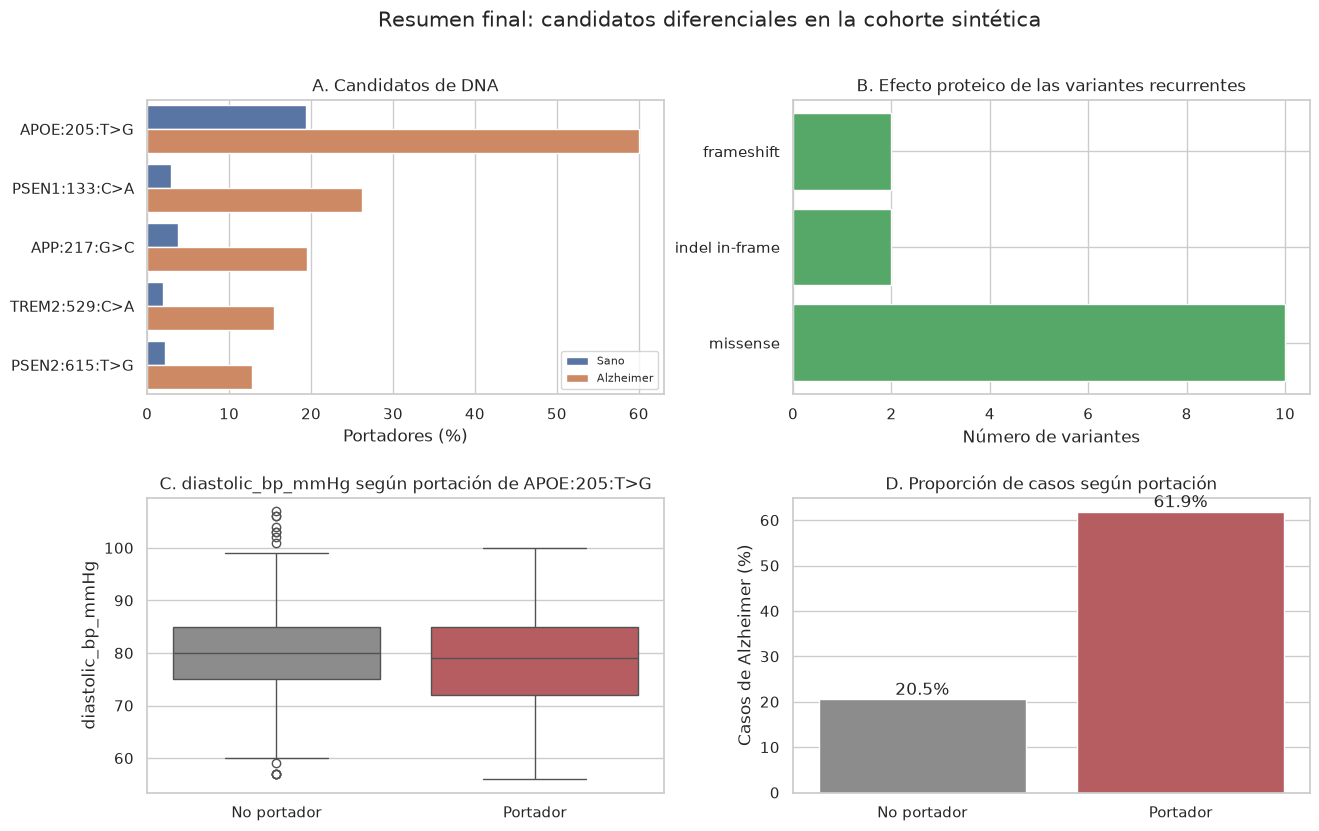

In [18]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# A. Variantes de DNA candidatas
ax1 = fig.add_subplot(gs[0, 0])
datos = candidatos.melt(id_vars="variante_id",
                        value_vars=["pct_sano", "pct_alzheimer"],
                        var_name="grupo", value_name="pct")
datos["grupo"] = datos["grupo"].map({"pct_sano": "Sano", "pct_alzheimer": "Alzheimer"})
sns.barplot(data=datos, y="variante_id", x="pct", hue="grupo", palette=PALETA, ax=ax1)
ax1.set(title="A. Candidatos de DNA", xlabel="Portadores (%)", ylabel="")
ax1.legend(title="", fontsize=8)

# B. Efecto proteico de los candidatos
ax2 = fig.add_subplot(gs[0, 1])
conteo = criterios["efecto_proteico"].value_counts()
ax2.barh(conteo.index, conteo.values, color="#55A868")
ax2.set(title="B. Efecto proteico de las variantes recurrentes",
        xlabel="Número de variantes", ylabel="")

# C. Perfil clinico del candidato principal
ax3 = fig.add_subplot(gs[1, 0])
if var_cl in VARS_BINARIAS:
    sns.barplot(data=datos_c, x="grupo_interes", y=var_cl, hue="grupo_interes",
                palette=PALETA_PORTADOR, legend=False, ax=ax3)
    ax3.set(ylabel="Prevalencia (%)")
else:
    sns.boxplot(data=base, x="grupo_interes", y=var_cl, hue="grupo_interes",
                palette=PALETA_PORTADOR, legend=False, ax=ax3)
ax3.set(title=f"C. {var_cl} según portación de {VARIANTE_FOCO}", xlabel="")

# D. Diagnostico por portacion
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(data=datos_d, x="grupo_interes", y="alzheimer", hue="grupo_interes",
            palette=PALETA_PORTADOR, legend=False, ax=ax4)
for i, v in enumerate(datos_d["alzheimer"]):
    ax4.text(i, v + 1, f"{v:.1f}%", ha="center")
ax4.set(title="D. Proporción de casos según portación", xlabel="",
        ylabel="Casos de Alzheimer (%)")

fig.suptitle("Resumen final: candidatos diferenciales en la cohorte sintética",
             fontsize=15, y=0.98)
guardar_figura("resumen_final_proyecto")
plt.show()

---
## 9. Conclusiones

> Completar con los valores que entregue la ejecución. Deben ser 3–5 conclusiones en lenguaje
> simple, tal como pide la guía, y consensuadas por el grupo.

1. Aplicando los cinco criterios sobre ... variantes recurrentes, ... alcanzaron el puntaje máximo.
2. El candidato principal es ..., presente en ...% de los casos y ...% de los controles.
3. Su efecto proteico es ..., lo que conecta la observación genética con un cambio molecular.
4. Los portadores muestran ... en ..., aunque parte de esa diferencia puede reflejar que la
   variante está enriquecida en casos y no un efecto propio de la variante.
5. Ningún candidato separa los grupos por sí solo: hay controles portadores y casos no portadores.

### Limitaciones

- **Los umbrales son decisiones del grupo.** Cambiar `MIN_PORTADORES` o `MIN_DIF_PUNTOS`
  cambia la lista de candidatos. Están declarados en la sección 0 precisamente para poder
  discutirlos.
- **El puntaje no es una métrica estadística.** Es un recuento de criterios cumplidos, útil para
  ordenar y justificar, no para inferir.
- **Confusión por diagnóstico.** Las diferencias clínicas entre portadores y no portadores pueden
  ser un reflejo de que la variante es más frecuente en casos, no un efecto de la variante.
  La comparación estratificada del notebook 01 es el camino para separar ambas cosas.
- **No hay pruebas de hipótesis ni corrección por comparaciones múltiples.** Se evaluaron muchas
  variantes contra muchas variables clínicas; con suficientes comparaciones, algunas diferencias
  aparecen por azar.
- **Datos sintéticos.** Las asociaciones fueron introducidas por el generador. Nada de lo aquí
  observado es evidencia clínica ni permite afirmar causalidad.

### Preguntas de defensa que este notebook deja cubiertas

| Pregunta | Dónde está la respuesta |
|---|---|
| ¿Por qué esos candidatos y no otros? | Secciones 2 y 3 (cinco criterios explícitos y puntaje) |
| ¿Qué criterio usaron para "recurrente"? | Sección 0 (`MIN_PORTADORES`, decisión declarada) |
| ¿Cómo conectaron DNA, proteína y clínica? | Secciones 3 y 6 (tabla y figura integrada) |
| ¿Los portadores son distintos clínicamente? | Sección 4 (perfil completo) |
| ¿Eso demuestra que la variante causa la enfermedad? | Sección 8 (confusión por diagnóstico y limitaciones) |
| ¿Qué pasaría si cambian los umbrales? | Sección 0 y limitaciones (la lista cambia; por eso están declarados) |
| ¿Por qué no aplicaron una prueba estadística? | Sección 8 (comparaciones múltiples; la guía pide análisis descriptivo) |
